In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from dataclasses import dataclass, asdict, field
from typing import List, Tuple
import os

os.makedirs('result', exist_ok=True)
np.random.seed(42)

In [28]:
@dataclass
class DevelopConfig:
    # 시뮬레이션 설정
    T: float = 1.0  # 정규화된 시간 (장 마감 = 1)
    sigma: float = 2.0
    gamma: float = 0.1
    A: float = 140.0
    k: float = 1.5
    q0: float = 0.0  # 초기 Net Delta (float으로 변경)
    
    # 방향성 체결 확률 버킷
    buckets: List[Tuple[float, float]] = field(default_factory=lambda: [
        (0.02, 1.0),
        (0.05, 1.5),
        (0.10, 2.5),
        (float('inf'), 3.5)
    ])

config = DevelopConfig()

In [29]:
# 실제 옵션 데이터 로드
data_path = '../crawling/data/kospi200_option_B0164815_20260323_1326.csv'
df_raw = pd.read_csv(data_path, encoding='utf-8-sig')

# Mid Price 계산: (매도호가1 + 매수호가1) / 2
df_raw['mid_price'] = (df_raw['옵션매도호가1'] + df_raw['옵션매수호가1']) / 2

# 필요한 컬럼 추출
option_data = df_raw[['시간', 'mid_price', '옵션델타', '옵션매도호가1', '옵션매수호가1']].copy()
option_data.columns = ['time', 'mid_price', 'delta', 'ask', 'bid']

# Outlier 탐지 및 처리
def detect_outliers_pct_change(series, threshold=5.0):
    """급격한 변화율로 outlier 탐지 (threshold % 이상 변화)"""
    pct_change = series.pct_change().abs() * 100
    # 앞뒤로 급변하는 경우 outlier로 판단
    outlier_mask = (pct_change > threshold) & (pct_change.shift(-1) > threshold)
    return outlier_mask

# Mid price 기반 outlier 탐지
outlier_mask_price = detect_outliers_pct_change(option_data['mid_price'], threshold=3.0)

# Delta 기반 outlier 탐지 (0.4~0.45 범위는 outlier로 판단)
delta_median = option_data['delta'].median()
outlier_mask_delta = (option_data['delta'] >= 0.4) & (option_data['delta'] <= 0.45)

# 전체 outlier mask
outlier_mask = outlier_mask_price | outlier_mask_delta
n_outliers = outlier_mask.sum()

print(f"=== Outlier 처리 ===")
print(f"Mid price 기반 outlier: {outlier_mask_price.sum()}개")
print(f"Delta 기반 outlier (0.4~0.45): {outlier_mask_delta.sum()}개")
print(f"총 outlier 개수: {n_outliers}")
if n_outliers > 0:
    print(f"Outlier 위치: {option_data[outlier_mask].index.tolist()}")

# Outlier를 NaN으로 대체 후 linear interpolation
option_data.loc[outlier_mask, ['mid_price', 'delta', 'ask', 'bid']] = np.nan
option_data = option_data.interpolate(method='linear')

# 데이터 요약
print(f"\n=== 옵션 데이터 요약 (Outlier 처리 후) ===")
print(f"데이터 개수: {len(option_data)}")
print(f"Mid Price 범위: {option_data['mid_price'].min():.2f} ~ {option_data['mid_price'].max():.2f}")
print(f"Delta 범위: {option_data['delta'].min():.4f} ~ {option_data['delta'].max():.4f}")
print(f"실제 스프레드: {(option_data['ask'] - option_data['bid']).mean():.2f}")

# 시뮬레이션용 배열 추출
mid_prices = option_data['mid_price'].values
deltas = option_data['delta'].values
n_steps = len(mid_prices) - 1
dt = config.T / n_steps

print(f"\nn_steps: {n_steps}, dt: {dt:.6f}")

=== Outlier 처리 ===
Mid price 기반 outlier: 1개
Delta 기반 outlier (0.4~0.45): 0개
총 outlier 개수: 1
Outlier 위치: [2731]

=== 옵션 데이터 요약 (Outlier 처리 후) ===
데이터 개수: 6427
Mid Price 범위: 37.45 ~ 43.17
Delta 범위: 0.4767 ~ 0.4808
실제 스프레드: 6.74

n_steps: 6426, dt: 0.000156


C:\Users\adg01\AppData\Local\Temp\ipykernel_2940\3629237535.py:40: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  option_data = option_data.interpolate(method='linear')


In [30]:
# Net Delta 기반 RP 계산 (q 대신 q_delta 사용)
def compute_reservation_price(s: float, q_delta: float, t: float, config: DevelopConfig) -> float:
    """
    Reservation Price 계산 (Net Delta 기반)
    r = s - q_delta * gamma * sigma^2 * (T - t)
    
    q_delta: Net Delta (계약수 × 옵션델타)
    """
    tau = config.T - t
    return s - q_delta * config.gamma * (config.sigma ** 2) * tau

def compute_optimal_spread(t: float, config: DevelopConfig) -> float:
    tau = config.T - t
    return config.gamma * (config.sigma ** 2) * tau + (2 / config.gamma) * np.log(1 + config.gamma / config.k)

def compute_quotes(s: float, q_delta: float, t: float, config: DevelopConfig) -> Tuple[float, float]:
    r = compute_reservation_price(s, q_delta, t, config)
    spread = compute_optimal_spread(t, config)
    return r - spread / 2, r + spread / 2

def get_fill_multiplier(price_change_pct: float, config: DevelopConfig) -> float:
    abs_change = abs(price_change_pct)
    for threshold, multiplier in config.buckets:
        if abs_change < threshold:
            return multiplier
    return config.buckets[-1][1]

def compute_fill_probability_develop(delta: float, s_current: float, s_next: float, 
                                      is_bid: bool, config: DevelopConfig, dt: float, is_last_step: bool) -> float:
    """delta here is the distance from mid to quote, not option delta"""
    if delta <= 0:
        return 1.0
    
    base_intensity = config.A * np.exp(-config.k * delta)
    base_prob = min(base_intensity * dt, 1.0)
    
    if is_last_step:
        return base_prob
    
    price_change_pct = (s_next - s_current) / s_current * 100
    multiplier = get_fill_multiplier(price_change_pct, config)
    
    # 양방향 승수 적용
    if price_change_pct > 0:  # 가격 상승
        if not is_bid:  # ask
            return min(base_prob * multiplier, 1.0)
        else:  # bid
            return max(base_prob / multiplier, 0.0)
    elif price_change_pct < 0:  # 가격 하락
        if is_bid:  # bid
            return min(base_prob * multiplier, 1.0)
        else:  # ask
            return max(base_prob / multiplier, 0.0)
    else:
        return base_prob

In [31]:
@dataclass
class SimulationState:
    step: int
    time: float
    mid_price: float
    option_delta: float  # 해당 시점의 옵션 델타
    contracts: int  # 계약 수
    net_delta: float  # Net Delta (계약수 × 옵션델타)
    cash: float
    reservation_price: float
    spread: float
    bid: float
    ask: float
    bid_fill: bool
    ask_fill: bool
    bid_prob: float = 0.0
    ask_prob: float = 0.0
    price_change_pct: float = 0.0
    multiplier: float = 1.0
    bid_fill_price: float = 0.0
    ask_fill_price: float = 0.0


def run_develop_simulation(config: DevelopConfig, mid_prices: np.ndarray, 
                           deltas: np.ndarray, dt: float) -> List[SimulationState]:
    """
    실제 옵션 데이터 기반 시뮬레이션
    - mid_prices: 옵션 mid price 배열
    - deltas: 옵션 델타 배열
    - dt: 정규화된 시간 간격
    """
    n_steps = len(mid_prices) - 1
    contracts = 0  # 계약 수
    net_delta = config.q0  # Net Delta
    cash = 0.0
    history = []
    
    for step in range(n_steps):
        t = step * dt
        s = mid_prices[step]
        option_delta = deltas[step]
        is_last_step = (step == n_steps - 1)
        s_next = mid_prices[step + 1] if not is_last_step else s
        
        # Net Delta 기반 RP 및 호가 계산
        r = compute_reservation_price(s, net_delta, t, config)
        spread = compute_optimal_spread(t, config)
        bid, ask = compute_quotes(s, net_delta, t, config)
        
        delta_bid = s - bid  # 호가 거리 (옵션 델타와 다름)
        delta_ask = ask - s
        
        prob_bid = compute_fill_probability_develop(delta_bid, s, s_next, True, config, dt, is_last_step)
        prob_ask = compute_fill_probability_develop(delta_ask, s, s_next, False, config, dt, is_last_step)
        
        bid_fill = np.random.random() < prob_bid
        ask_fill = np.random.random() < prob_ask
        
        # 실제 체결 가격 결정: delta <= 0 이면 mid price로 체결
        bid_fill_price = s if delta_bid <= 0 else bid
        ask_fill_price = s if delta_ask <= 0 else ask
        
        price_change_pct = (s_next - s) / s * 100 if not is_last_step else 0.0
        multiplier = get_fill_multiplier(price_change_pct, config) if not is_last_step else 1.0
        
        state = SimulationState(
            step=step, time=t, mid_price=s, option_delta=option_delta,
            contracts=contracts, net_delta=net_delta, cash=cash,
            reservation_price=r, spread=spread, bid=bid, ask=ask,
            bid_fill=bid_fill, ask_fill=ask_fill,
            bid_prob=prob_bid, ask_prob=prob_ask,
            price_change_pct=price_change_pct, multiplier=multiplier,
            bid_fill_price=bid_fill_price, ask_fill_price=ask_fill_price
        )
        history.append(state)
        
        # 체결 시 포지션 업데이트
        if bid_fill:
            contracts += 1
            net_delta += option_delta  # 델타 증가
            cash -= bid_fill_price
        if ask_fill:
            contracts -= 1
            net_delta -= option_delta  # 델타 감소
            cash += ask_fill_price
    
    # 최종 상태
    final_state = SimulationState(
        step=n_steps, time=config.T, mid_price=mid_prices[-1], option_delta=deltas[-1],
        contracts=contracts, net_delta=net_delta, cash=cash,
        reservation_price=mid_prices[-1], spread=0, bid=mid_prices[-1], ask=mid_prices[-1],
        bid_fill=False, ask_fill=False, bid_prob=0.0, ask_prob=0.0,
        price_change_pct=0.0, multiplier=1.0, bid_fill_price=0.0, ask_fill_price=0.0
    )
    history.append(final_state)
    return history

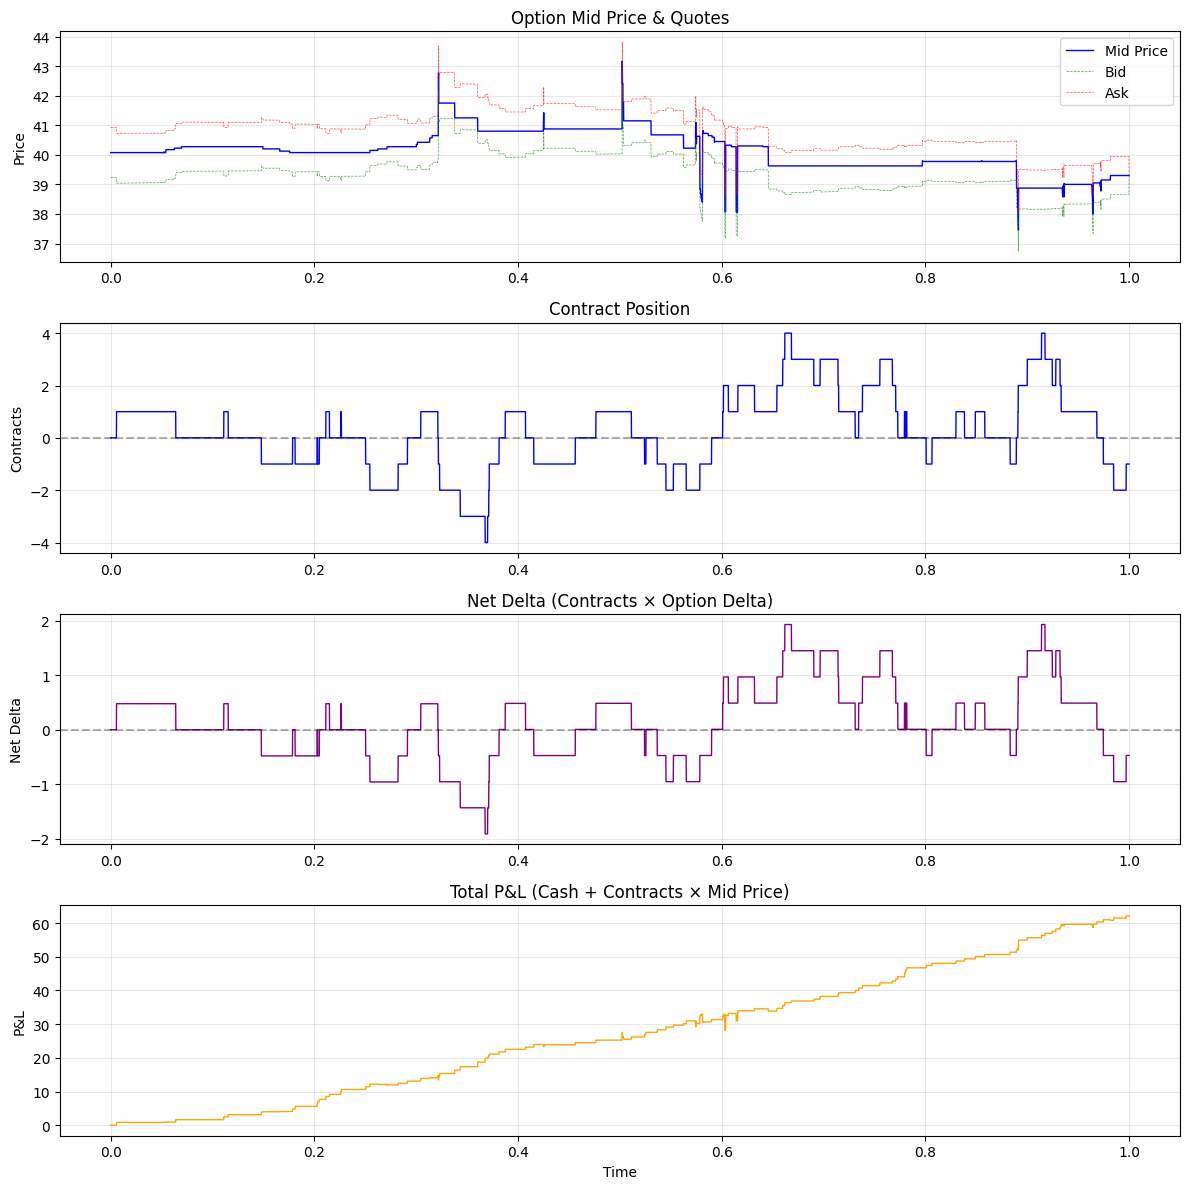

=== 시뮬레이션 결과 ===
Final Contracts: -1
Final Net Delta: -0.4725
Final Cash: 101.44
Final P&L: 62.14


In [32]:
# 실제 데이터로 시뮬레이션 실행
np.random.seed(42)
history = run_develop_simulation(config, mid_prices, deltas, dt)

# 결과 추출
times = [s.time for s in history]
mid_price_hist = [s.mid_price for s in history]
bid_hist = [s.bid for s in history]
ask_hist = [s.ask for s in history]
contracts_hist = [s.contracts for s in history]
net_delta_hist = [s.net_delta for s in history]
cash_hist = [s.cash for s in history]
pnl = [cash_hist[i] + contracts_hist[i] * mid_price_hist[i] for i in range(len(history))]  # 수정: contracts * mid_price

# CSV 저장
df_result = pd.DataFrame([asdict(s) for s in history])
df_result['pnl'] = pnl
df_result.to_csv('result/optimize_simulation_history.csv', index=False)

# 시각화
fig, axes = plt.subplots(4, 1, figsize=(12, 12))

# 1. 가격 및 호가
axes[0].plot(times, mid_price_hist, 'b-', label='Mid Price', linewidth=1)
axes[0].plot(times, bid_hist, 'g--', label='Bid', alpha=0.7, linewidth=0.5)
axes[0].plot(times, ask_hist, 'r--', label='Ask', alpha=0.7, linewidth=0.5)
axes[0].set_ylabel('Price')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_title('Option Mid Price & Quotes')

# 2. 계약 수
axes[1].plot(times, contracts_hist, 'blue', linewidth=1)
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[1].set_ylabel('Contracts')
axes[1].grid(True, alpha=0.3)
axes[1].set_title('Contract Position')

# 3. Net Delta
axes[2].plot(times, net_delta_hist, 'purple', linewidth=1)
axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[2].set_ylabel('Net Delta')
axes[2].grid(True, alpha=0.3)
axes[2].set_title('Net Delta (Contracts × Option Delta)')

# 4. P&L
axes[3].plot(times, pnl, 'orange', linewidth=1)
axes[3].set_xlabel('Time')
axes[3].set_ylabel('P&L')
axes[3].grid(True, alpha=0.3)
axes[3].set_title('Total P&L (Cash + Contracts × Mid Price)')

plt.tight_layout()
plt.savefig('result/optimize_single_simulation.png', dpi=150)
plt.show()

# 최종 결과 출력
final = history[-1]
print(f"=== 시뮬레이션 결과 ===")
print(f"Final Contracts: {final.contracts}")
print(f"Final Net Delta: {final.net_delta:.4f}")
print(f"Final Cash: {final.cash:.2f}")
print(f"Final P&L: {pnl[-1]:.2f}")

In [33]:
# 시뮬레이션 통계
immediate_fills = sum(1 for s in history[:-1] if s.bid_prob == 1.0 or s.ask_prob == 1.0)
bid_fills = sum(1 for s in history[:-1] if s.bid_fill)
ask_fills = sum(1 for s in history[:-1] if s.ask_fill)

print(f"=== Develop Mode Statistics ===")
print(f"Total steps: {n_steps}")
print(f"Bid fills: {bid_fills}, Ask fills: {ask_fills}")
print(f"Immediate fills (delta <= 0): {immediate_fills}")
print(f"\nOption Delta 범위: {min(s.option_delta for s in history):.4f} ~ {max(s.option_delta for s in history):.4f}")
print(f"Net Delta 범위: {min(s.net_delta for s in history):.4f} ~ {max(s.net_delta for s in history):.4f}")

print(f"\nBucket distribution:")
for threshold, mult in config.buckets:
    count = sum(1 for s in history[:-1] if get_fill_multiplier(s.price_change_pct, config) == mult)
    print(f"  multiplier {mult}: {count} steps")

=== Develop Mode Statistics ===
Total steps: 6426
Bid fills: 43, Ask fills: 44
Immediate fills (delta <= 0): 0

Option Delta 범위: 0.4767 ~ 0.4808
Net Delta 범위: -1.9111 ~ 1.9309

Bucket distribution:
  multiplier 1.0: 6327 steps
  multiplier 1.5: 0 steps
  multiplier 2.5: 14 steps
  multiplier 3.5: 85 steps


In [34]:
# 동일한 가격 경로에서 여러 번 시뮬레이션 (체결 확률의 랜덤성만 다르게)
def run_multiple_simulations(config: DevelopConfig, mid_prices: np.ndarray, 
                              deltas: np.ndarray, dt: float, n_simulations: int = 1000):
    results = {
        'final_pnl': [], 
        'final_contracts': [], 
        'final_net_delta': [],
        'immediate_fills': []
    }
    
    for i in range(n_simulations):
        np.random.seed(i)
        history = run_develop_simulation(config, mid_prices, deltas, dt)
        final = history[-1]
        final_pnl = final.cash + final.contracts * final.mid_price  # 수정: contracts * mid_price
        
        results['final_pnl'].append(final_pnl)
        results['final_contracts'].append(final.contracts)
        results['final_net_delta'].append(final.net_delta)
        results['immediate_fills'].append(sum(1 for s in history[:-1] if s.bid_prob == 1.0 or s.ask_prob == 1.0))
    
    return results

print("Running 1000 simulations on real option data...")
sim_results = run_multiple_simulations(config, mid_prices, deltas, dt, 1000)

print(f"\n=== Multiple Simulation Results (1000 runs) ===")
print(f"P&L: mean = {np.mean(sim_results['final_pnl']):.2f}, std = {np.std(sim_results['final_pnl']):.2f}")
print(f"Final Contracts: mean = {np.mean(sim_results['final_contracts']):.2f}, std = {np.std(sim_results['final_contracts']):.2f}")
print(f"Final Net Delta: mean = {np.mean(sim_results['final_net_delta']):.4f}, std = {np.std(sim_results['final_net_delta']):.4f}")
print(f"Immediate fills per sim: mean = {np.mean(sim_results['immediate_fills']):.1f}")

Running 1000 simulations on real option data...

=== Multiple Simulation Results (1000 runs) ===
P&L: mean = 67.23, std = 8.05
Final Contracts: mean = -0.08, std = 4.08
Final Net Delta: mean = -0.0378, std = 1.9606
Immediate fills per sim: mean = 0.0


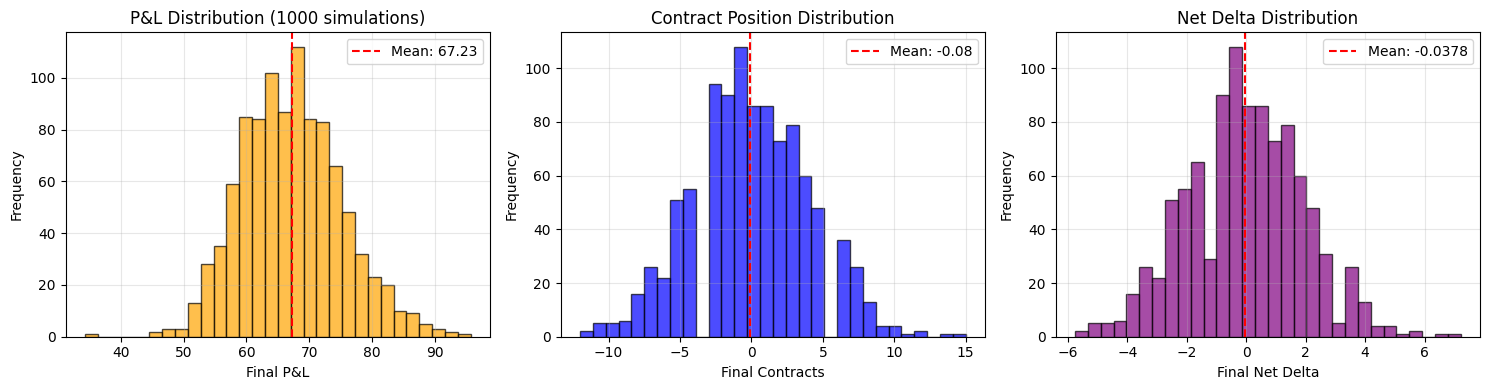

In [35]:
# P&L 및 Net Delta 분포 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# P&L 분포
axes[0].hist(sim_results['final_pnl'], bins=30, alpha=0.7, color='orange', edgecolor='black')
axes[0].axvline(x=np.mean(sim_results['final_pnl']), color='red', linestyle='--', label=f"Mean: {np.mean(sim_results['final_pnl']):.2f}")
axes[0].set_xlabel('Final P&L')
axes[0].set_ylabel('Frequency')
axes[0].set_title('P&L Distribution (1000 simulations)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Contracts 분포
axes[1].hist(sim_results['final_contracts'], bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[1].axvline(x=np.mean(sim_results['final_contracts']), color='red', linestyle='--', label=f"Mean: {np.mean(sim_results['final_contracts']):.2f}")
axes[1].set_xlabel('Final Contracts')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Contract Position Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Net Delta 분포
axes[2].hist(sim_results['final_net_delta'], bins=30, alpha=0.7, color='purple', edgecolor='black')
axes[2].axvline(x=np.mean(sim_results['final_net_delta']), color='red', linestyle='--', label=f"Mean: {np.mean(sim_results['final_net_delta']):.4f}")
axes[2].set_xlabel('Final Net Delta')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Net Delta Distribution')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('result/optimize_distributions.png', dpi=150)
plt.show()